<a href="https://colab.research.google.com/github/pradipdas9040/Machine-Learning-2/blob/main/AgenticAI/05_Iterative_flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
!pip install langchain-ollama

In [2]:
%%capture
!sudo apt-get install -y zstd

In [3]:
%%capture
!curl -fsSL https://ollama.com/install.sh | sh

In [4]:
# Start Ollama service in the background
import subprocess
import os

# Set OLLAMA_HOST to '0.0.0.0' to make it accessible from inside the Colab VM.
os.environ['OLLAMA_HOST'] = '0.0.0.0'

# Terminate existing Ollama process if running
if 'ollama_process' in globals() and ollama_process.poll() is None:
    ollama_process.terminate()
    ollama_process.wait()
    print("Previous Ollama server terminated.")

# Start Ollama server in a new process
ollama_process = subprocess.Popen(['ollama', 'serve'])

# Wait a bit for the server to start (adjust if needed)
import time
time.sleep(10) # Increased sleep time for server to fully initialize

print("Ollama server started.")

Ollama server started.


In [5]:
%%capture
!ollama pull qwen2.5:3b
!ollama pull mistral:latest
!ollama pull llama2:7b-chat

In [6]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
import operator
from langchain_core.messages import SystemMessage, HumanMessage

### Define Specialized LLM Models

Here we define three separate `ChatOllama` instances, each intended for a distinct role in the workflow:

1.  **Generator Model**: Responsible for generating content (e.g., initial responses, creative text).
2.  **Evaluator Model**: Focuses on evaluating generated content, sentiment, or other aspects.
3.  **Optimizer Model**: Aims to refine or improve existing content or decisions based on given criteria.

We can specify different Ollama models for each role to leverage their specific strengths (e.g., a summarization model for evaluation, a creative model for generation). For now, `qwen2.5:3b` is used as a default for all three.

In [7]:
generator_model = ChatOllama(
    model="llama2:7b-chat",
    temperature=0.7 # A higher temperature for more creative generation
)
print("Generator model defined.")

Generator model defined.


In [8]:
evaluator_model = ChatOllama(
    model="mistral:latest",
    temperature=0 # A lower temperature for more deterministic evaluation
)
print("Evaluator model defined.")

Evaluator model defined.


In [9]:
optimizer_model = ChatOllama(
    model="qwen2.5:3b",
    temperature=0.5 # A moderate temperature for balanced optimization
)
print("Optimizer model defined.")

Optimizer model defined.


In [10]:
class XState(TypedDict):
  topic: str
  x: str
  evaluation: Literal["Approved", "NeedImprovement"]
  feedback: str
  iteration: int
  max_itr: int

class XEvaluation(BaseModel):
  evaluation: Literal["Approved", "NeedImprovement"] = Field(..., description="Whether the tweet is approved or needs improvement.")
  feedback: str = Field(..., description="Constructive feedback for the tweet")

structured_evaluator_model = evaluator_model.with_structured_output(XEvaluation)

In [11]:
def generate_x(state: XState) -> dict:

  message = [
      SystemMessage(content="You are a funny and a clever Twitter/X influencer"),
      HumanMessage(
          content=f"""
            Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

            Rules:
            - Do NOT use question-answer format.
            - Max 280 characters.
            - Use observational humor, irony, sarcasm, or cultural references.
            - Think in meme logic, punchlines, or relatable takes.
            - Use simple, day to day english
            - This is version {state['iteration'] + 1} of the tweet.
          """
      )
  ]

  responce = generator_model.invoke(message).content
  return {"x": responce}

def evaluate_x(state: XState) -> dict:
  message = [
      SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
      HumanMessage(
          content=f"""
            Evaluate the following tweet:

            Tweet: "{state['x']}"

            Use the criteria below to evaluate the tweet:

            1. Originality – Is this fresh, or have you seen it a hundred times before?
            2. Humor – Did it genuinely make you smile, laugh, or chuckle?
            3. Punchiness – Is it short, sharp, and scroll-stopping?
            4. Virality Potential – Would people retweet or share it?
            5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

            Auto-reject if:
            - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
            - It exceeds 280 characters
            - It reads like a traditional setup-punchline joke
            - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

            ### Respond ONLY in structured format:
            - evaluation: "approved" or "needs_improvement"
            - feedback: One paragraph explaining the strengths and weaknesses
          """
      )
  ]
  responce = structured_evaluator_model.invoke(message)
  return {"evaluation": responce.evaluation, "feedback": responce.feedback}

def optimize_x(state: XState) -> dict:
  messages = [
      SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
      HumanMessage(
      content=f"""
          Improve the tweet based on this feedback:
          "{state['feedback']}"

          Topic: "{state['topic']}"
          Original Tweet:
          {state['x']}

          Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
        """
      )
  ]
  responce = optimizer_model.invoke(messages).content
  iteration = state["iteration"] + 1

  return {"x": responce, "iteration": iteration}

def route_evaluation(state: XState):

  if state["evaluation"] == "Approved" or state["iteration"] >= state["max_itr"]:
    return "Approved"
  else:
    return "NeedImprovement"

In [12]:
graph = StateGraph(XState)

graph.add_node("generate", generate_x)
graph.add_node("evaluate", evaluate_x)
graph.add_node("optimize", optimize_x)

graph.add_edge(START, "generate")
graph.add_edge("generate", "evaluate")
graph.add_conditional_edges("evaluate", route_evaluation, {"Approved": END, "NeedImprovement": "optimize"})
graph.add_edge("optimize", "evaluate")

workflow = graph.compile()

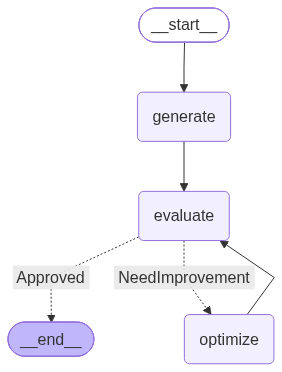

In [13]:
workflow

In [14]:
initial_state = {
    "topic": "Indian Cricket Team",
    "iteration": 1,
    "max_itr": 3
}

result = workflow.invoke(initial_state)

In [15]:
result

{'topic': 'Indian Cricket Team',
 'x': ' "Indian Cricket Team: Where mediocrity meets fanaticism. 🏏😂 They\'re so good at losing, it\'s like they have a PhD in defeat! 🎓 #CricketTeam #India #LosingIsFun"',
 'evaluation': 'Approved',
 'feedback': 'The tweet demonstrates a good balance of originality, humor, and punchiness. The comparison of the Indian cricket team to a PhD in defeat is an interesting and humorous take on their recent performance. The use of emojis adds to the overall impact of the tweet, making it more engaging. However, while the tweet is well-formed, it could potentially benefit from a more concise or creative conclusion to further enhance its virality potential.',
 'iteration': 1,
 'max_itr': 3}

In [16]:
initial_state2 = {
    "topic": "Indian Rail",
    "iteration": 1,
    "max_itr": 3
}

result2 = workflow.invoke(initial_state2)

In [17]:
result2

{'topic': 'Indian Rail',
 'x': "🚂 Indian Rail: where the trains are so slow, you'll have more time to scroll through your phone and regret not buying a ticket for the next available flight! 😅 #IndianRailProblems #TrainLife",
 'evaluation': 'Approved',
 'feedback': "This tweet is a well-crafted example of humorously expressing common frustrations, which is sure to resonate with many. The originality lies in its unique take on the frequent issues faced by Indian Rail passengers, making it less repetitive compared to other similar jokes. The punchiness comes from its concise and witty format, which is both short and sharp, making it scroll-stopping. The virality potential is high due to its relatable content and clever use of hashtags. However, while the humor is present, it could be argued that it's not overtly laugh-out-loud funny but more of a chuckle-worthy tweet.",
 'iteration': 1,
 'max_itr': 3}

In [18]:
initial_state3 = {
    "topic": "Howrah Bridge",
    "iteration": 1,
    "max_itr": 3
}

result3 = workflow.invoke(initial_state3)

In [19]:
result3

{'topic': 'Howrah Bridge',
 'x': "🚨 Attention all Kolkatans! 🚨 Have you ever crossed the Howrah Bridge and wondered... why bother? 🤔 Like, what's on the other side that's worth braving the traffic and chaos? 😅 Maybe it's just me, but I'd rather take my chances with the Baghini than face another day of honking and sweat. 💦🚨 #HowrahBridgeProbs #KolkataLife",
 'evaluation': 'Approved',
 'feedback': "This tweet is a well-crafted example of humor, originality, and virality potential. The use of emojis adds to its visual appeal and makes it more engaging. The writer cleverly compares the stress of crossing the Howrah Bridge with the fear of Baghini (a notorious traffic intersection in Kolkata), which is a relatable sentiment for many locals. The punchiness of the tweet is evident as it's short, sharp, and scroll-stopping. The format is also well-formed, avoiding question-answer or setup-punchline structures, and staying under 280 characters. However, to further improve its virality potential